# EDA — Credit Risk Dataset

**Цель:** разведочный анализ данных, выявление пропусков, выбросов, дисбаланса классов.

**Данные:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset

**Вывод:** датасет несбалансирован (~78/22%), есть выбросы в `person_age` и `person_emp_length`, два признака содержат пропуски.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/credit_risk_dataset.csv')
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 1. Базовая информация

In [2]:
df.info()
print('\nПропуски:')
print(df.isnull().sum())
print('\nДубликаты:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB

Пропуски:
person_age                       0


## 2. Баланс классов

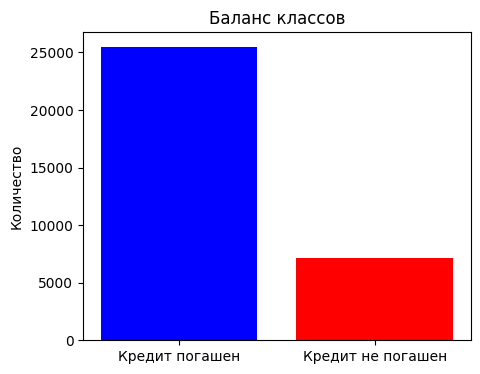

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['loan_status'].value_counts()
ax.bar(['Кредит погашен', 'Кредит не погашен'], counts.values, color = ['blue', 'red'])
ax.set_title('Баланс классов')
ax.set_ylabel('Количество')
plt.savefig('../artifacts/class_balance.png')
plt.show()

## 3. Распределение числовых признаков

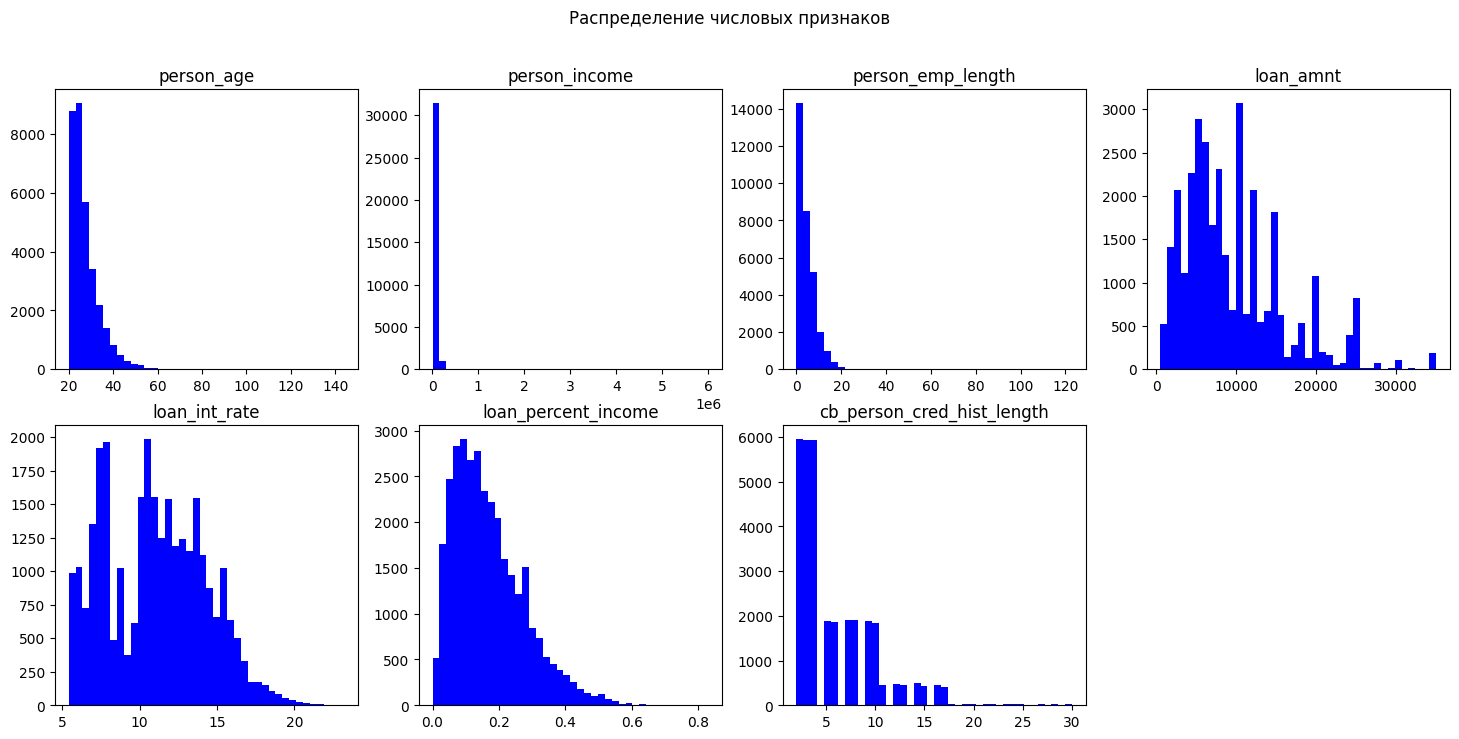

In [8]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='blue')
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Распределение числовых признаков')
plt.savefig('../artifacts/numeric_distributions.png')
plt.show()

## 4. Выбросы

In [9]:
print('Макс. возраст:', df['person_age'].max())
print('Макс. стаж:', df['person_emp_length'].max())
print('Строк с возрастом > 100:', (df['person_age'] > 100).sum())
print('Строк со стажем > 60:', (df['person_emp_length'] > 60).sum())

Макс. возраст: 144
Макс. стаж: 123.0
Строк с возрастом > 100: 5
Строк со стажем > 60: 2


## 5. Корреляционная матрица

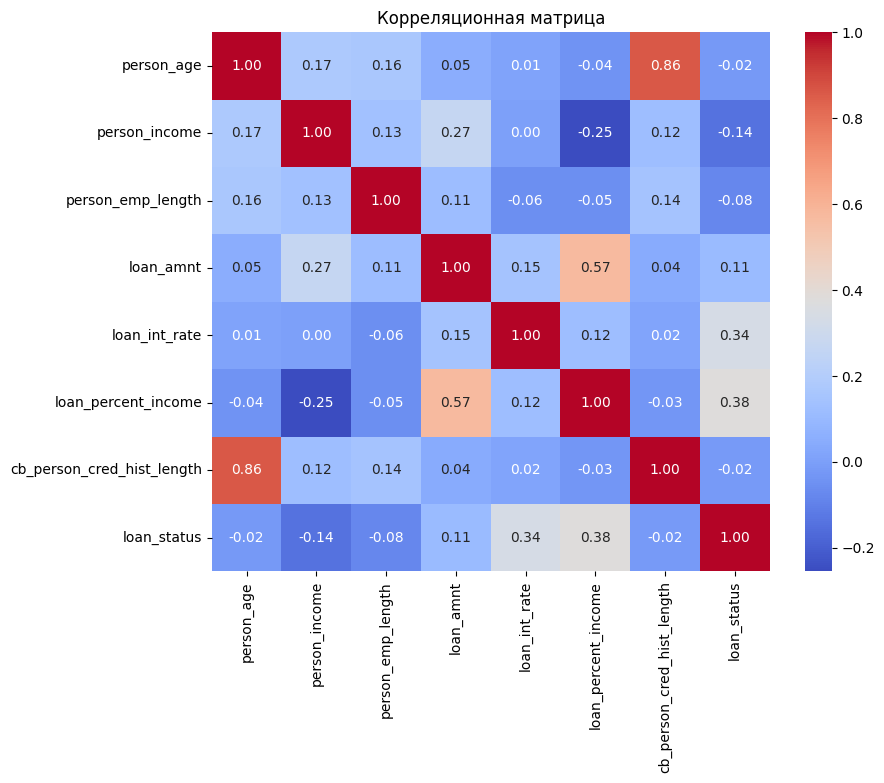

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Корреляционная матрица')
plt.savefig('../artifacts/correlation_matrix.png')
plt.show()

## 6. Категориальные признаки vs loan_status

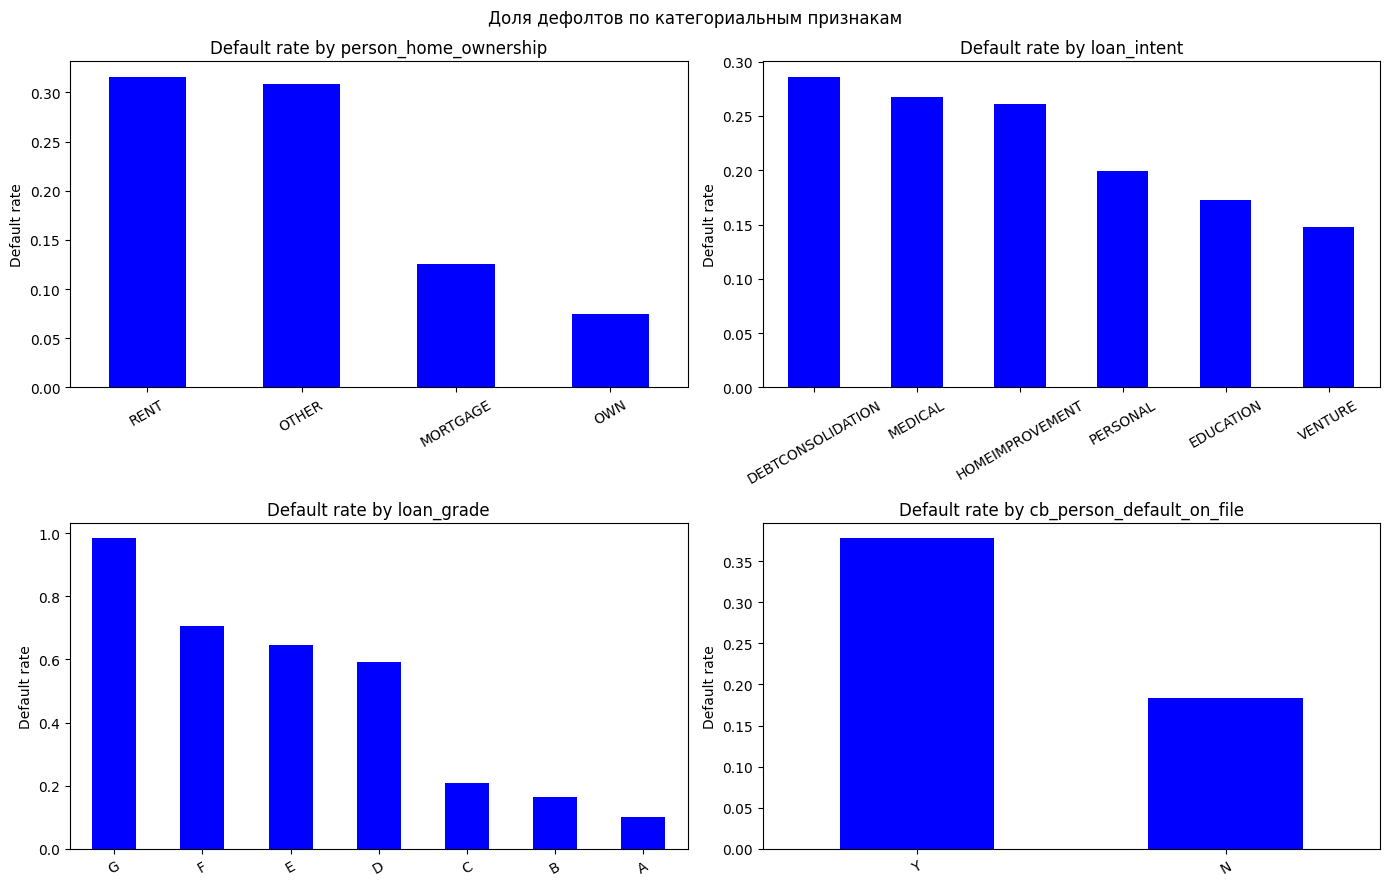

In [16]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    pivot = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    pivot.plot(kind='bar', ax=axes[i], color='blue')
    axes[i].set_title(f'Default rate by {col}')
    axes[i].set_ylabel('Default rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Доля дефолтов по категориальным признакам')
plt.tight_layout()
plt.savefig('../artifacts/categorical_default_rate.png')
plt.show()

## Выводы EDA

- Ярко выраженный дисбаланс классов
- Выбросы `person_age` до 144, `person_emp_length` до 123
- Есть пропуски в столбцах `loan_int_rate` и `person_emp_length`
- Сильная корркляция с таргетом `loan_grade`, `loan_int_rate`, `cb_person_default_on_file`